In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SA01.txt")

In [ ]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = 20  # Anzahl Anfragen pro Episode
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
pool_size = DRAUSP_data.pool_size

print(K)
print(T_d)
print(pool_size)

print(C_k)
print(instance)

4
20
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)

In [4]:
from training.dqn_agent import DQNAgent
from models.full_lattice import FullLatticeNetwork


agent = DQNAgent(
    env,
    QnetworkClass=lambda input_dim, output_dim: FullLatticeNetwork(
        input_dim     = input_dim,
        output_dim    = output_dim,
        c_range       = (0.0, 10.0),
        t_range       = (1.0, float(T_d)),
        r_range       = (0.0, 100.0),
        q_range       = (0.0, 10.0)
    ),
    monotonicity_penalty=False,
    reject_bias=0.75,
    gamma=0.99,
    epsilon_decay_steps=5000
)

In [5]:
reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=4000)

  Systematic monotonicity (Episode 1): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode   50/4000  Reward:   131.00  Avg(50):   294.16  Tiefe:   20  Avg-Tiefe(50):   19.8  ε: 0.838
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  100/4000  Reward:   389.00  Avg(50):   398.24  Tiefe:   20  Avg-Tiefe(50):   18.9  ε: 0.711
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  150/4000  Reward:   648.00  Avg(50):   431.54  Tiefe:   17  Avg-Tiefe(50):   17.2  ε: 0.614
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  200/4000  Reward:   404.00  Avg(50):   440.66  Tiefe:    8  Avg-Tiefe(50):   15.6  ε: 0.540
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  250/4000  Reward:   508.00  Avg(50):   454.38  Tiefe:   13  Avg-Tiefe(50):   14.8  ε:

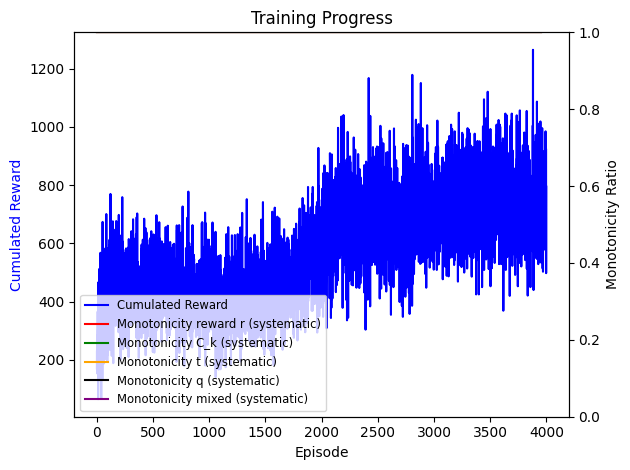

In [8]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

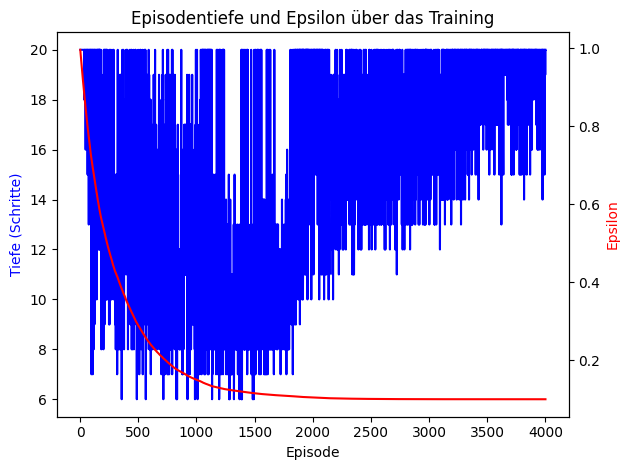

In [7]:
plot_depth_epsilon(depth_history)